# PBMC 3k end-to-end, on a pure scrust stack

The scanpy PBMC 3k clustering tutorial with **no scanpy anywhere** — not for computation,
not for loading, not for plotting:

* computation is `scrust` (`sr.pp`, `sr.tl`) on the Apple GPU (Metal via candle, plus the
  hand-written `knn` kernel behind `pp.neighbors`),
* the data is fetched as an `.h5ad` and read with `anndata` directly, and
* every figure is drawn by the native `scrust.pl` (`sr.pl`) module — publication-grade
  matplotlib/seaborn.

Nothing below imports scanpy or calls into it; the script AST-checks itself for that
before it runs. Run it as a script or open the executed notebook built with
`jupytext --to notebook`.

```bash
python docs/tutorials/pbmc3k_clustering.py
```

## Step 0 — Repository path setup

Put the repo's `python/` directory on `sys.path` so `import scrust` works no matter which
directory the script or notebook is launched from. This runs before any scrust import.

In [1]:
import sys
from pathlib import Path

# Automatically append repo root to sys.path so 'scrust' is importable.
repo_root = (
    Path(__file__).resolve().parents[2] if "__file__" in globals() else Path.cwd().parents[1]
)
if str(repo_root / "python") not in sys.path:
    sys.path.insert(0, str(repo_root / "python"))

## Step 1 — Imports and Metal GPU availability

`scrust` mirrors scanpy's module layout (`pp`, `tl`, `pl`), so the calls read the same; the
arithmetic runs in Rust. `sr.gpu_available()` reports whether Metal came up — when it did,
`device="auto"` puts every device-aware step on the GPU without the caller choosing.

In [2]:
import ast  # noqa: E402
import urllib.request  # noqa: E402

import anndata  # noqa: E402
import matplotlib  # noqa: E402

import scrust as sr  # noqa: E402

matplotlib.use("Agg")  # headless backend for figure files; sr.pl loads pyplot lazily after

FIGURE_DIR = repo_root / "docs" / "tutorials" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"scrust {sr.__version__} | Metal GPU available: {sr.gpu_available()}")

scrust 0.2.0 | Metal GPU available: True


## Compliance check — zero scanpy, anywhere

Parse this file and fail if it imports scanpy or uses the `sc` alias or `scanpy` name, so
nothing in the pipeline, the loader or the plotting can touch scanpy. It runs only as a
script (a notebook kernel has no `__file__`), so *Run All* in Jupyter skips it.

In [3]:
def _assert_no_scanpy(path: Path) -> None:
    """Fail if the source imports scanpy or uses the `sc` alias / `scanpy` name."""
    tree = ast.parse(path.read_text())
    offenders: list[str] = []
    for node in ast.walk(tree):
        if isinstance(node, ast.Import):
            offenders += [
                f"line {node.lineno}: import {a.name}"
                for a in node.names
                if a.name.split(".")[0] == "scanpy"
            ]
        elif isinstance(node, ast.ImportFrom):
            if (node.module or "").split(".")[0] == "scanpy":
                offenders.append(f"line {node.lineno}: from {node.module} import ...")
        elif isinstance(node, ast.Attribute):
            root = node.value
            while isinstance(root, ast.Attribute):
                root = root.value
            if isinstance(root, ast.Name) and root.id in {"sc", "scanpy"}:
                offenders.append(f"line {node.lineno}: {root.id}.{node.attr}")
    if offenders:
        raise AssertionError("scanpy usage found:\n  " + "\n  ".join(offenders))
    print("compliance: 0 scanpy imports and 0 sc/scanpy attribute calls")


if "__file__" in globals():
    _assert_no_scanpy(Path(__file__).resolve())

## Step 2 — Load PBMC 3k without scanpy

Fetch the raw `.h5ad` once (reusing any local copy) and read it with `anndata`. This is the
same 2 700-cell matrix scanpy's pbmc3k dataset returns, obtained without importing it.

In [4]:
def load_pbmc3k(cache_dir: Path) -> anndata.AnnData:
    """Return raw PBMC 3k as an AnnData, downloading the .h5ad only if no copy is cached."""
    url = "https://exampledata.scverse.org/scanpy/pbmc3k_raw.h5ad"
    cache_dir.mkdir(parents=True, exist_ok=True)
    target = cache_dir / "pbmc3k_raw.h5ad"
    for candidate in (target, repo_root / ".cache" / "scanpy" / "pbmc3k_raw.h5ad"):
        if candidate.exists():
            return anndata.read_h5ad(candidate)
    print(f"downloading pbmc3k_raw.h5ad from {url}")
    urllib.request.urlretrieve(url, target)  # trusted scverse data host
    return anndata.read_h5ad(target)


adata = load_pbmc3k(repo_root / ".cache")
adata.var_names_make_unique()
print(f"loaded {adata.n_obs} cells x {adata.n_vars} genes")

loaded 2700 cells x 32738 genes


## Step 3 — Quality control and filtering

Flag mitochondrial genes (a boolean column of `var`), then `sr.pp.calculate_qc_metrics`
fills the per-cell QC columns. Cells and genes are filtered with `sr.pp.filter_cells` /
`sr.pp.filter_genes`; the mitochondrial-fraction cut is plain AnnData boolean indexing.

In [5]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sr.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

sr.pp.filter_cells(adata, min_genes=200)
sr.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 5].copy()
print(f"after QC: {adata.n_obs} cells x {adata.n_vars} genes")

after QC: 2643 cells x 13714 genes


## Step 4 — Normalisation and log transform

Counts-per-10k normalisation followed by `log1p`. `adata.raw` keeps the full
log-normalised matrix, which the differential-expression and gene plots read back later.

In [6]:
sr.pp.normalize_total(adata, target_sum=1e4)
sr.pp.log1p(adata)
adata.raw = adata

## Step 5 — Highly variable genes and scaling

Select the 2000 most variable genes (Seurat flavour), subset to them, then z-score each
gene with `sr.pp.scale`. Scaling densifies, so subsetting to HVGs first keeps it small.

In [7]:
sr.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")
adata = adata[:, adata.var["highly_variable"].to_numpy()].copy()
sr.pp.scale(adata, zero_center=True, max_value=10)
print(f"kept {adata.n_vars} highly variable genes")

kept 2000 highly variable genes


## Step 6 — PCA

Truncated PCA (randomised SVD, on the GPU). Writes `obsm["X_pca"]`, `varm["PCs"]` and
`uns["pca"]`, which `sr.pl.pca_variance_ratio` reads.

In [8]:
sr.pp.pca(adata, n_comps=50, random_state=0)
print(f"obsm['X_pca'] {adata.obsm['X_pca'].shape}")

obsm['X_pca'] (2643, 50)


## Step 7 — k-NN graph, with the Metal GPU kernel

`device="auto"` routes the k-NN search to the hand-written `knn` Metal kernel on Apple
silicon (the first scrust GPU kernel on the call path), and to the candle CPU path
otherwise. Both produce the same neighbour graph — `tests/test_device_parity.py` pins them
equal. Writes `obsp["distances"]`, `obsp["connectivities"]`, `uns["neighbors"]`.

In [9]:
sr.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca", device="auto")
print(f"neighbour graph on {adata.n_obs} cells (device='auto')")

neighbour graph on 2643 cells (device='auto')


## Step 8 — Clustering and UMAP embedding

Leiden clustering over the neighbour graph, then a UMAP layout. Both read
`obsp["connectivities"]`; `sr.tl.leiden` writes `obs["leiden"]` and `sr.tl.umap` writes
`obsm["X_umap"]`.

In [10]:
sr.tl.leiden(adata, resolution=1.0, key_added="leiden")
sr.tl.umap(adata, random_state=0)
n_clusters = adata.obs["leiden"].nunique()
print(f"{n_clusters} Leiden clusters; obsm['X_umap'] {adata.obsm['X_umap'].shape}")

10 Leiden clusters; obsm['X_umap'] (2643, 2)


## Step 9 — Differential expression (marker genes)

Rank marker genes per cluster with the Wilcoxon rank-sum test on the **log-normalised**
matrix (recovered from `adata.raw`), not the scaled one, because fold changes on z-scored
data are meaningless.

In [11]:
ranked = adata.raw.to_adata()[:, adata.var_names].copy()
ranked.obs["leiden"] = adata.obs["leiden"]
sr.tl.rank_genes_groups(ranked, "leiden", method="wilcoxon")
top = ranked.uns["rank_genes_groups"]["names"][0]
print(f"top marker per cluster: {list(top)}")

top marker per cluster: ['RPL13', 'LTB', 'S100A9', 'CD74', 'CCL5', 'LST1', 'NKG7', 'HLA-DPA1', 'PF4', 'KIAA0101']


## Step 10 — Visualisation with the native `sr.pl` module

Four publication-grade figures, all drawn by `scrust.pl`: the PCA elbow, the UMAP coloured
by Leiden cluster (categorical, seaborn `husl`), the UMAP coloured by a marker gene
(continuous `viridis`, read from `adata.raw`), and the marker-gene ranking per cluster.

In [12]:
marker = next(
    (g for g in ("NKG7", "CST3", "MS4A1", "PPBP") if g in adata.raw.var_names),
    adata.raw.var_names[0],
)

sr.pl.pca_variance_ratio(adata, n_pcs=30, show=False, save=FIGURE_DIR / "pca_variance_ratio.png")
sr.pl.umap(adata, color="leiden", show=False, save=FIGURE_DIR / "umap_leiden.png")
sr.pl.umap(
    adata, color=marker, title=f"{marker} expression",
    show=False, save=FIGURE_DIR / "umap_gene.png",
)
sr.pl.rank_genes_groups(
    ranked, n_genes=10, n_cols=4, show=False, save=FIGURE_DIR / "rank_genes_groups.png"
)
print(f"figures written to {FIGURE_DIR} (coloured UMAP marker gene: {marker})")

figures written to /Users/Shared/runDE/docs/tutorials/figures (coloured UMAP marker gene: NKG7)


## Results gallery

Display the figures written above inline. Under a notebook kernel this embeds the images
in the executed output; a plain script run detects it is not interactive and skips it.

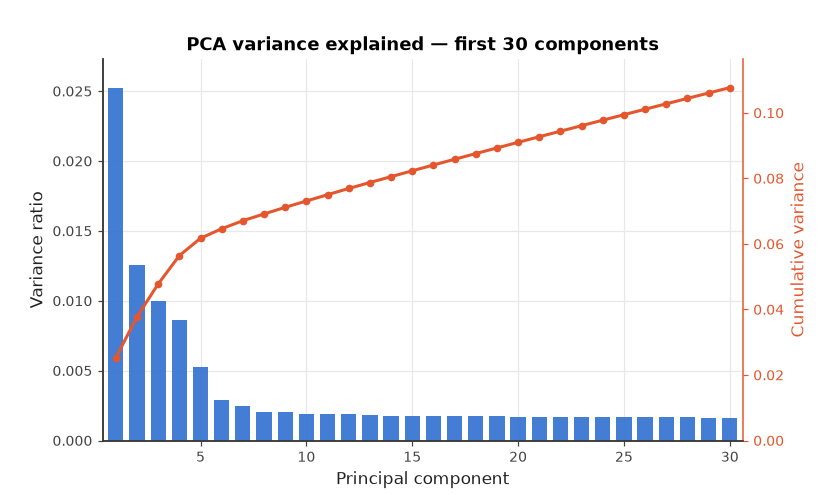

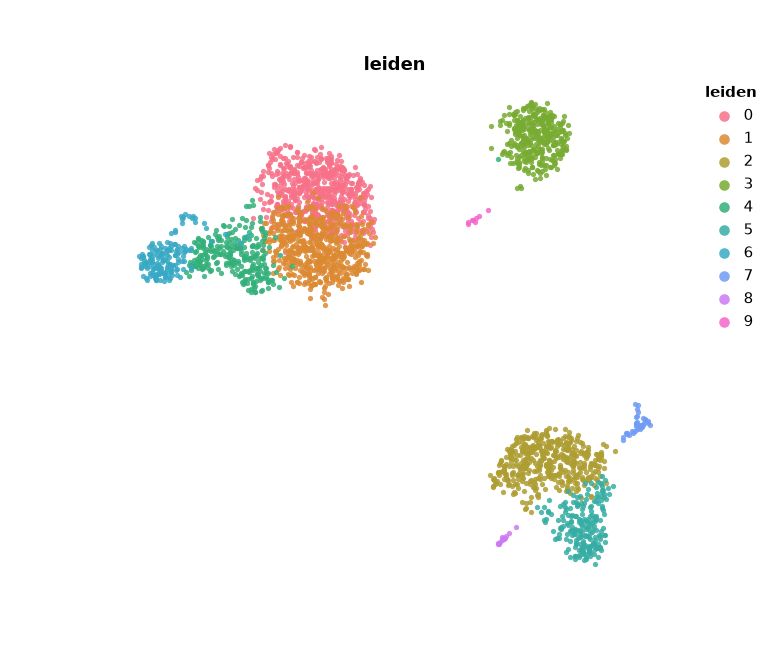

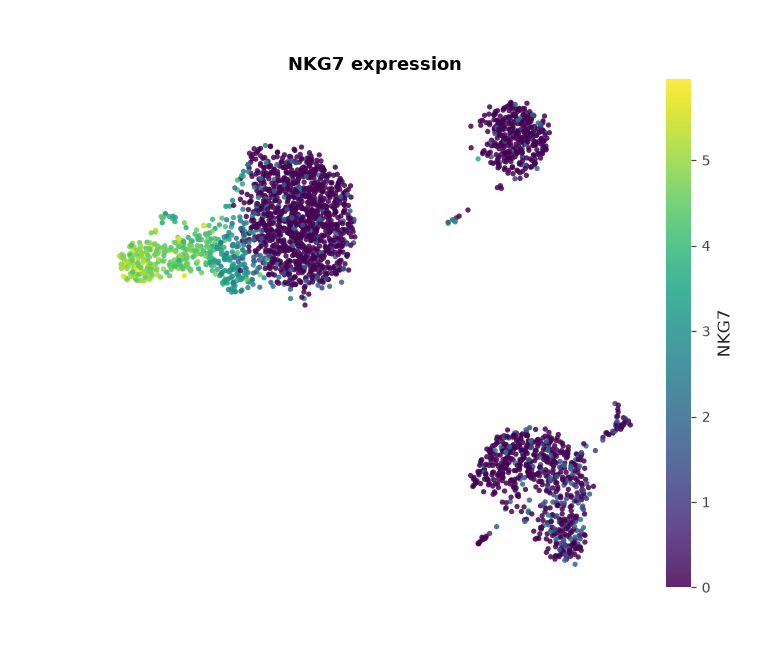

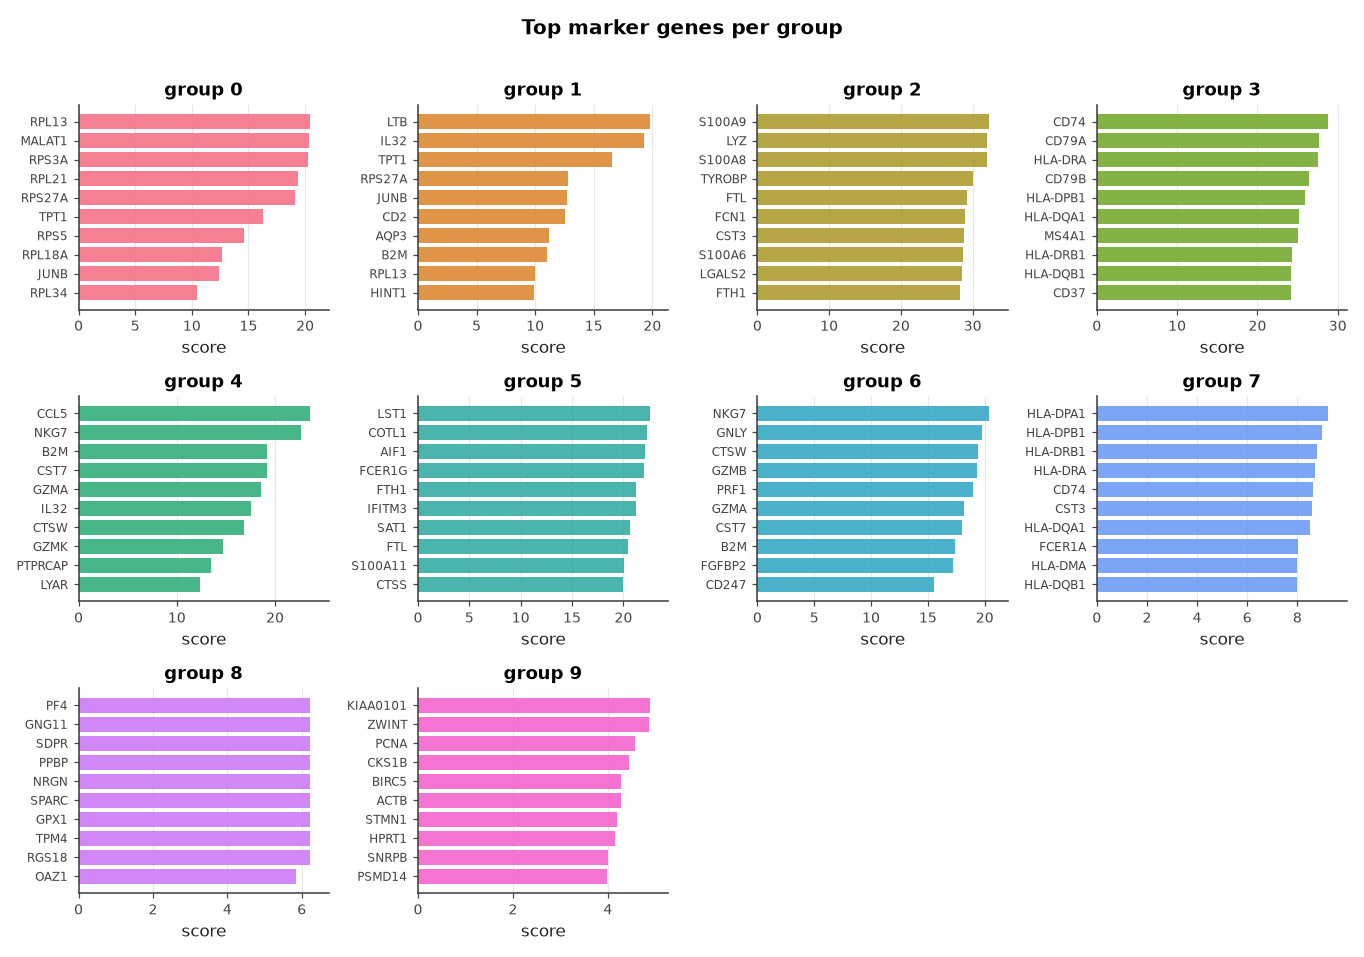

In [13]:
try:
    from IPython import get_ipython

    _interactive = get_ipython() is not None
except ImportError:
    _interactive = False

if _interactive:
    from IPython.display import Image, display

    for _name in (
        "pca_variance_ratio.png",
        "umap_leiden.png",
        "umap_gene.png",
        "rank_genes_groups.png",
    ):
        display(Image(filename=str(FIGURE_DIR / _name)))